In [ ]:
# [setup]
# Recreates july_canonical_v2026-06-29.ipynb [plot-desktop], adding:
#  (1) the Aug-trough BEST-FIT model (aug22-retune sampling round, config s01) WITH its corresponding
#      Win10-headwind change (the tau* that pins its Dec-15 28d-MA at the SAME 48,585,483 as July's,
#      so only the summer trough differs), and
#  (2) horizontal lines at the summer trough for the July forecast (green) and the best-fit.
import os, subprocess, glob, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

DESKTOP_FORECAST_PATH = "data-official/2026-07/desktop_locked/mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"
PREV_FORECAST_DESKTOP_PATH = "data-official/2026-06/desktop_cps0.15983_thresh050_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-26.ld-D.raw.plus_iran.parquet"
# Best-fit = aug22-retune LHS sample s01: multiplicative, cps=0.1849, cpr=0.734, recent=17, ncp=35.
BESTFIT_FORECAST_PATH = "research/param-scans/aug22-retune/sampling/s01/cps0.1849_thresh032_recent17_cpr0.734_ncp35_clip0.6_sps0.00825_regimemultiplicative/mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"

ADJUSTMENTS_DIR = "data-official/2026-07/adjustments"          # July headwind: desktop -1,345,000
PREV_ADJUSTMENTS_DIR = "data-official/2026-06/adjustments"     # June headwind: desktop -1,420,000

DISPLAY_START = pd.Timestamp("2026-01-01"); DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-07-06"); PREV_FORECAST_START = pd.Timestamp("2026-05-26")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
TROUGH_WINDOW = (pd.Timestamp("2026-07-15"), pd.Timestamp("2026-10-01"))   # summer-trough search window
BQ_START = "2025-12-04"

# Best-fit Win10 headwind. Anchor = base -1,370,000 + tau, where tau is the tunable "how much has
# Prophet already absorbed" component (it REPLACES the current +25K belief; it does NOT stack on it).
# Best-fit tau* = +85,032  ->  anchor -1,284,968, which pins the best-fit Dec-15 28d-MA at 48,585,483
# (same as July). NET CHANGE FROM THE CURRENT +25K = +85,032 - 25,000 = +60,032 (a ~60K further
# softening of the headwind; anchor -1,345,000 -> -1,284,968). Derived analytically in aug22-retune.
BESTFIT_HEADWIND_DESKTOP = -1_284_968

os.chdir(subprocess.run(['git','rev-parse','--show-toplevel'], capture_output=True, text=True).stdout.strip())


In [2]:
# [helpers]
import sys
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma  # variance-matched seam-smoothed MA (matches canonical)

def render_adjustment(spec, date_index):
    idx = pd.DatetimeIndex(date_index)
    desktop = pd.Series(0.0, index=idx); mobile = pd.Series(0.0, index=idx)
    if spec["type"] == "linear_ramp":
        start = pd.Timestamp(spec["start_date"]); anchor = pd.Timestamp(spec["anchor_date"])
        total = (anchor - start).days
        elapsed = np.maximum(0, (idx - start).days)
        desktop[:] = spec.get("desktop_dau", 0) * elapsed / total
        mobile[:] = spec.get("mobile_dau", 0) * elapsed / total
    return {"desktop": desktop, "mobile": mobile}

def load_adjustments(adjustments_dir, date_index):
    idx = pd.DatetimeIndex(date_index)
    d = pd.Series(0.0, index=idx); m = pd.Series(0.0, index=idx)
    for path in sorted(glob.glob(f"{adjustments_dir}/*.json")):
        with open(path) as f: spec = json.load(f)
        r = render_adjustment(spec, idx); d += r["desktop"]; m += r["mobile"]
    return {"desktop": d, "mobile": m}

def headwind_net(desktop_anchor, date_index):
    """Custom linear-ramp headwind with a given desktop anchor (for the best-fit tau*)."""
    spec = {"type": "linear_ramp", "start_date": "2026-04-01", "anchor_date": "2026-12-15",
            "desktop_dau": desktop_anchor, "mobile_dau": 0}
    return render_adjustment(spec, date_index)

def apply_net_adjustment(ma_series, net, platform, forecast_start):
    result = ma_series.copy()
    mask = result.index >= forecast_start
    adj = net[platform].reindex(result.index, fill_value=0.0)
    result[mask] += adj[mask]
    return result

def load_all_level_dau(path, data_source, segment_filter, app_filter):
    df = pd.read_parquet(path)
    mask = ((df["country"]=="ALL") & (df["segment"]==segment_filter)
            & (df["data_source"]==data_source) & (df["app_name"]==app_filter))
    r = df.loc[mask, ["target_date","dau","data_type"]].copy()
    r["target_date"] = pd.to_datetime(r["target_date"])
    return r.sort_values("target_date").reset_index(drop=True)

def daily_to_28ma(dates, values):
    s = pd.Series(values.values, index=pd.to_datetime(dates.values))
    return s.sort_index().rolling(28).mean()


In [3]:
# [load]
desktop_raw = load_all_level_dau(DESKTOP_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
prev_desktop_raw = load_all_level_dau(PREV_FORECAST_DESKTOP_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
bestfit_raw = load_all_level_dau(BESTFIT_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop")
print(f"rows — July {len(desktop_raw)} | prior June {len(prev_desktop_raw)} | best-fit {len(bestfit_raw)}")


rows — July 2922 | prior June 2922 | best-fit 2922


In [4]:
# [bq-actuals]
client = bigquery.Client(project="moz-fx-data-bq-data-science")
sql = f"""SELECT submission_date AS date, SUM(dau) AS dau
  FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
  WHERE app_name = "Firefox Desktop"
    AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
  GROUP BY submission_date ORDER BY 1"""
desktop_actuals = client.query(sql).to_dataframe()
desktop_actuals["date"] = pd.to_datetime(desktop_actuals["date"])
print(f"desktop actuals: {len(desktop_actuals)} rows, through {desktop_actuals['date'].max().date()}")


desktop actuals: 217 rows, through 2026-07-08


In [5]:
# [compute-series]
# Forecast curves use display_ma (variance-matched seam-smoothed) to match the canonical plot;
# actuals use plain daily_to_28ma.
july_ma_raw = display_ma(desktop_raw["target_date"], desktop_raw["dau"], FORECAST_START)
idx = july_ma_raw.index
net = load_adjustments(ADJUSTMENTS_DIR, idx)
prev_net = load_adjustments(PREV_ADJUSTMENTS_DIR, idx)

# July current (green): -1,345,000 headwind.
desktop_ma = apply_net_adjustment(july_ma_raw, net, "desktop", FORECAST_START)

# Best-fit (s01) with its OWN headwind anchor (tau* -> -1,284,968) so Dec-15 matches July's.
bestfit_ma_raw = display_ma(bestfit_raw["target_date"], bestfit_raw["dau"], FORECAST_START)
bestfit_ma = apply_net_adjustment(bestfit_ma_raw, headwind_net(BESTFIT_HEADWIND_DESKTOP, bestfit_ma_raw.index),
                                  "desktop", FORECAST_START)

# Prior June (blue): reproduce the DELIVERED June curve incl. the +500K MozillaOnline step (as canonical).
prev_desktop_ma = apply_net_adjustment(
    display_ma(prev_desktop_raw["target_date"], prev_desktop_raw["dau"], PREV_FORECAST_START),
    prev_net, "desktop", PREV_FORECAST_START)
def june_mo_ma_tailwind(spec, date_index, platform):
    ix = pd.DatetimeIndex(date_index); amp = float(spec.get(f"{platform}_dau", 0))
    if amp == 0: return pd.Series(0.0, index=ix)
    start = pd.Timestamp(spec["start_date"]); window = int(spec.get("ma_window", 28))
    step = pd.Series(np.where(ix >= start, amp, 0.0), index=ix).sort_index()
    return step.rolling(window, min_periods=window).mean().fillna(0.0)
with open("data-official/2026-06/mozillaonline/june_delivered_mo_tailwind.json") as f:
    june_mo_spec = json.load(f)
prev_desktop_ma = prev_desktop_ma + june_mo_ma_tailwind(june_mo_spec, prev_desktop_ma.index, "desktop")

desktop_actual_ma = daily_to_28ma(desktop_actuals["date"], desktop_actuals["dau"])

def trough(s):
    w = s[(s.index >= TROUGH_WINDOW[0]) & (s.index <= TROUGH_WINDOW[1])].dropna()
    return w.idxmin(), w.min()
july_trough_date, july_trough = trough(desktop_ma)
bestfit_trough_date, bestfit_trough = trough(bestfit_ma)
print(f"July trough    : {july_trough:>13,.0f}  on {july_trough_date.date()}")
print(f"Best-fit trough: {bestfit_trough:>13,.0f}  on {bestfit_trough_date.date()}")
print(f"Trough lift    : {bestfit_trough - july_trough:>+13,.0f}")
print(f"Dec-15 — July {desktop_ma.get(MEASUREMENT_DATE):,.0f} | best-fit {bestfit_ma.get(MEASUREMENT_DATE):,.0f} "
      f"(gap {bestfit_ma.get(MEASUREMENT_DATE)-desktop_ma.get(MEASUREMENT_DATE):+,.0f})")


July trough    :    43,246,576  on 2026-08-22
Best-fit trough:    44,708,372  on 2026-08-25
Trough lift    :    +1,461,797
Dec-15 — July 48,585,483 | best-fit 48,585,483 (gap -0)


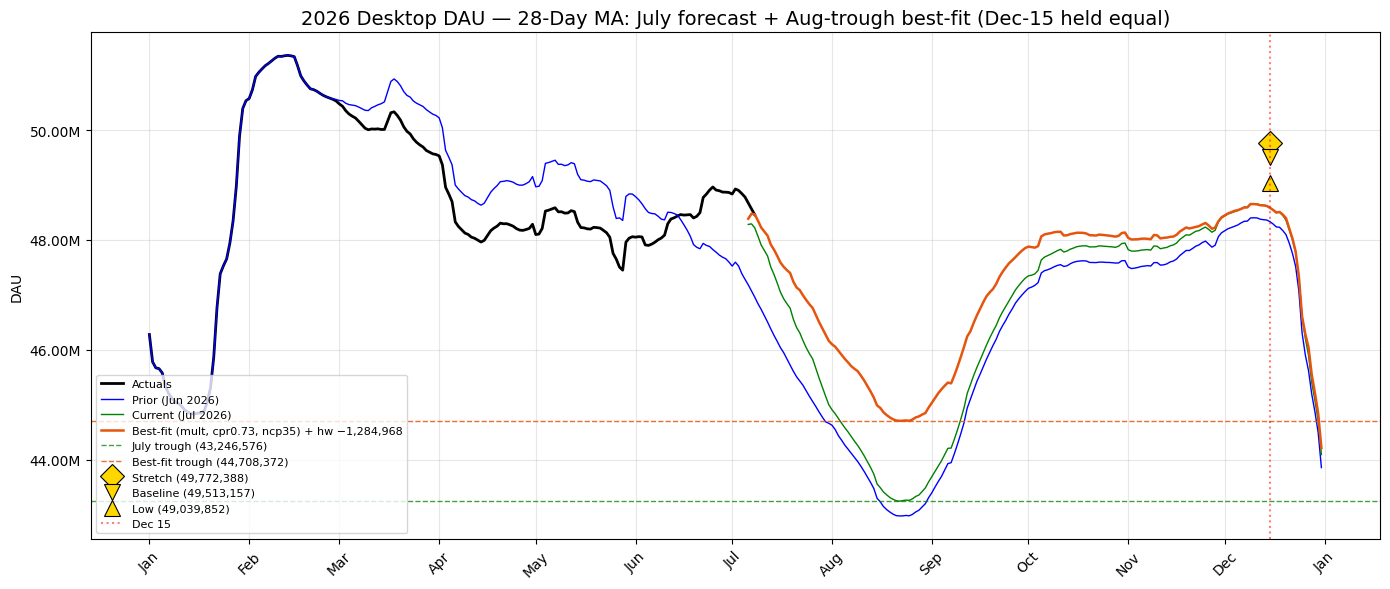

In [6]:
# [plot-desktop]
def clip_display(s): return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()
def clip_forecast_only(s, fs=FORECAST_START): return s[(s.index >= fs) & (s.index <= DISPLAY_END)].dropna()
def millions_formatter(x, pos): return f"{x/1e6:.2f}M"

STAKEHOLDER_DESKTOP_LOW = 49_039_852
STAKEHOLDER_DESKTOP_BASELINE = 49_513_157
STAKEHOLDER_DESKTOP_STRETCH = 49_772_388
BESTFIT_COLOR = "#e6550d"

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(clip_display(desktop_actual_ma), label="Actuals", color="black", linewidth=2)
ax.plot(clip_display(prev_desktop_ma), label="Prior (Jun 2026)", color="blue", linewidth=1)
ax.plot(clip_forecast_only(desktop_ma), label="Current (Jul 2026)", color="green", linewidth=1)
ax.plot(clip_forecast_only(bestfit_ma), color=BESTFIT_COLOR, linewidth=1.8,
        label=f"Best-fit (mult, cpr0.73, ncp35) + hw −{abs(BESTFIT_HEADWIND_DESKTOP):,}")

# Horizontal lines at the summer trough: July (green) and the best-fit approach.
ax.axhline(july_trough, color="green", linestyle="--", linewidth=1, alpha=0.75,
           label=f"July trough ({july_trough:,.0f})")
ax.axhline(bestfit_trough, color=BESTFIT_COLOR, linestyle="--", linewidth=1, alpha=0.85,
           label=f"Best-fit trough ({bestfit_trough:,.0f})")

for value, marker, label in [(STAKEHOLDER_DESKTOP_STRETCH, "D", "Stretch"),
                             (STAKEHOLDER_DESKTOP_BASELINE, "v", "Baseline"),
                             (STAKEHOLDER_DESKTOP_LOW, "^", "Low")]:
    ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold", markersize=12,
            markeredgecolor="black", markeredgewidth=0.8, linestyle="None", label=f"{label} ({value:,})")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")

ax.set_title("2026 Desktop DAU — 28-Day MA: July forecast + Aug-trough best-fit (Dec-15 held equal)", fontsize=14)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc="lower left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs("research/param-scans/aug22-retune/plots", exist_ok=True)
plt.savefig("research/param-scans/aug22-retune/plots/desktop_bestfit_vs_july.png", dpi=110, bbox_inches="tight")
plt.show()
